# Project 20 — Institutional Alpha Research Pipeline
### Full Systematic Investment System

Demonstrates a simplified version of a systematic equity research workflow:
universe management → 10-factor cross-sectional signal generation →
constrained QP portfolio optimisation (CVXPY, sector-neutral, dollar-neutral) →
walk-forward backtest with realistic transaction costs →
Fama-French 5-Factor performance attribution.

All data is fetched live from Yahoo Finance and the Ken French Data Library.


| Component | Method |
|-----------|--------|
| Universe | 50 large-cap S&P 500 names, 11 GICS sectors |
| Signals | 10 factors — momentum, reversal, low-vol, value, quality |
| Covariance | Ledoit-Wolf shrinkage (rolling 252-day window) |
| Optimisation | CVXPY QP: dollar-neutral, sector-neutral, gross ≤ 2× |
| Backtest | Walk-forward, monthly rebalance, no look-ahead bias |
| Transaction Costs | 10 bps one-way flat transaction cost assumption |
| Attribution | Fama-French 5-Factor OLS, Newey-West standard errors |


In [2]:
%pip install -q yfinance pandas-datareader cvxpy scipy scikit-learn statsmodels plotly kaleido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.4 MB/s eta 0:00:00


In [3]:
import warnings, time, logging
warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import yfinance as yf
import pandas_datareader.data as web
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.covariance import LedoitWolf

# ── Dark theme ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",   "text.color": "#e6edf3",
    "axes.labelcolor": "#e6edf3",  "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",      "grid.color": "#21262d",
    "grid.linewidth": 0.6,         "axes.grid": True,
    "font.family": "monospace",    "figure.dpi": 120,
})
ACCENT, GREEN, RED, ORANGE, PURPLE = "#58a6ff","#3fb950","#f85149","#d29922","#bc8cff"

# ── Timeline ───────────────────────────────────────────────────────────────────
DATA_START     = "2018-01-01"
BACKTEST_START = "2020-01-01"
BACKTEST_END   = "2024-12-31"
ESTIMATION_DAYS = 252

print("Imports loaded.")
print(f"Backtest window : {BACKTEST_START}  ->  {BACKTEST_END}")


Imports loaded.
Backtest window : 2020-01-01  ->  2024-12-31


## Section 1 — Universe Construction & Data Pipeline

We use 50 large-cap S&P 500 constituents for liquidity and sector diversity.
Survivorship-bias note: this list reflects current membership. A production
system would join a point-in-time constituent table at each rebalancing date.
The code architecture is identical; only the universe feed changes.


In [4]:
UNIVERSE = [
    # Technology
    "AAPL","MSFT","NVDA","AVGO","ORCL","CSCO","IBM","TXN","QCOM","ADBE",
    # Communication Services
    "GOOGL","META","NFLX","VZ","T",
    # Consumer Discretionary
    "AMZN","TSLA","HD","MCD","NKE",
    # Consumer Staples
    "WMT","PG","KO","PEP","PM",
    # Financials
    "JPM","BAC","GS","WFC","V","MA","SPGI",
    # Health Care
    "UNH","LLY","JNJ","MRK","ABT","TMO","ISRG","DHR",
    # Industrials
    "CAT","RTX","HON","UPS",
    # Energy
    "XOM","CVX",
    # Materials
    "LIN",
    # Real Estate
    "PLD",
    # Utilities
    "NEE",
    # Other
    "BRK-B","ACN","CRM",
]

SECTOR_MAP = {
    "AAPL":"Technology","MSFT":"Technology","NVDA":"Technology","AVGO":"Technology",
    "ORCL":"Technology","CSCO":"Technology","IBM":"Technology","TXN":"Technology",
    "QCOM":"Technology","ADBE":"Technology","ACN":"Technology","CRM":"Technology",
    "GOOGL":"Comm Svcs","META":"Comm Svcs","NFLX":"Comm Svcs","VZ":"Comm Svcs","T":"Comm Svcs",
    "AMZN":"Cons Disc","TSLA":"Cons Disc","HD":"Cons Disc","MCD":"Cons Disc","NKE":"Cons Disc",
    "WMT":"Cons Staples","PG":"Cons Staples","KO":"Cons Staples","PEP":"Cons Staples","PM":"Cons Staples",
    "JPM":"Financials","BAC":"Financials","GS":"Financials","WFC":"Financials",
    "V":"Financials","MA":"Financials","SPGI":"Financials","BRK-B":"Financials",
    "UNH":"Health Care","LLY":"Health Care","JNJ":"Health Care","MRK":"Health Care",
    "ABT":"Health Care","TMO":"Health Care","ISRG":"Health Care","DHR":"Health Care",
    "CAT":"Industrials","RTX":"Industrials","HON":"Industrials","UPS":"Industrials",
    "XOM":"Energy","CVX":"Energy",
    "LIN":"Materials",
    "PLD":"Real Estate",
    "NEE":"Utilities",
}

print(f"Universe: {len(UNIVERSE)} tickers across {len(set(SECTOR_MAP.values()))} sectors")


Universe: 52 tickers across 11 sectors


In [5]:
print("Downloading price data (30-60s) ...")

raw = yf.download(
    UNIVERSE, start=DATA_START, end=BACKTEST_END,
    auto_adjust=True, progress=False, threads=True,
)

prices  = raw["Close"].copy()
volumes = raw["Volume"].copy()

# Drop tickers with >15% missing observations
min_cov = 0.85
prices  = prices.loc[:, prices.notna().mean()  >= min_cov]
volumes = volumes.loc[:, volumes.notna().mean() >= min_cov]

prices  = prices.ffill().dropna(how="all")
volumes = volumes.ffill().dropna(how="all")

shared  = prices.columns.intersection(volumes.columns).tolist()
prices  = prices[shared]
volumes = volumes[shared]

# ── Returns ────────────────────────────────────────────────────────────────────
returns     = prices.pct_change().dropna(how="all")
log_returns = np.log(prices / prices.shift(1)).dropna(how="all")

market_returns = returns.mean(axis=1)   # Equal-weight market proxy

# SPY benchmark
spy_raw     = yf.download("SPY", start=DATA_START, end=BACKTEST_END,
                           auto_adjust=True, progress=False)
spy_returns = spy_raw["Close"].pct_change().dropna()
spy_returns.name = "SPY"

print(f"Tickers     : {len(shared)}")
print(f"Date range  : {prices.index[0].date()}  ->  {prices.index[-1].date()}")
print(f"Trading days: {len(prices)}")


Tickers     : 52
Date range  : 2018-01-02  ->  2024-12-30
Trading days: 1760


In [6]:
# yfinance .info is a current snapshot — NOT point-in-time.
# In this project, book-to-price and ROE are included as static cross-sectional fundamental proxies.
# This is useful for demonstrating the research pipeline, but it introduces potential look-ahead bias.
# A production-quality version should replace these fields with point-in-time fundamentals.

print("Fetching fundamentals (~50 tickers, ~60s) ...")

FUND_FIELDS = [
    "priceToBook","trailingPE","returnOnEquity","grossMargins",
    "debtToEquity","currentRatio","beta","revenueGrowth",
    "earningsGrowth","marketCap","operatingMargins","returnOnAssets",
]

records = []
for i, ticker in enumerate(shared):
    try:
        info = yf.Ticker(ticker).info
        rec  = {"ticker": ticker}
        for f in FUND_FIELDS:
            rec[f] = info.get(f, np.nan)
        records.append(rec)
    except Exception:
        records.append({"ticker": ticker})
    time.sleep(0.15)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(shared)} done ...")

fundamentals = pd.DataFrame(records).set_index("ticker")
fundamentals["book_to_price"]  = 1 / fundamentals["priceToBook"].replace(0, np.nan)
fundamentals["earnings_yield"] = 1 / fundamentals["trailingPE"].replace(0, np.nan)
fundamentals["log_mktcap"]     = np.log(fundamentals["marketCap"].replace(0, np.nan))

print("Fundamental coverage:")
print(fundamentals.notna().mean().sort_values().apply(lambda x: f"{x:.0%}").to_string())


Fetching fundamentals (~50 tickers, ~60s) ...
  10/52 done ...
  20/52 done ...
  30/52 done ...
  40/52 done ...
  50/52 done ...
Fundamental coverage:
debtToEquity         88%
currentRatio         94%
returnOnEquity       96%
earningsGrowth       98%
grossMargins        100%
trailingPE          100%
beta                100%
priceToBook         100%
revenueGrowth       100%
marketCap           100%
operatingMargins    100%
returnOnAssets      100%
book_to_price       100%
earnings_yield      100%
log_mktcap          100%


## Section 2 — Signal Library

Ten cross-sectional alpha signals. All price-based signals are fully
point-in-time. Fundamental signals use a current snapshot (see note above).
Higher signal value = more attractive. Each signal is z-scored
cross-sectionally before entering the composite.

| # | Signal | Category | Source |
|---|--------|----------|--------|
| 1 | 12-1 Momentum | Momentum | Jegadeesh & Titman (1993) |
| 2 | 3-Month Momentum | Momentum | — |
| 3 | Short-Term Reversal | Reversal | Jegadeesh (1990) |
| 4 | Idiosyncratic Volatility | Low-Vol | Ang et al. (2006) |
| 5 | Beta (Low Beta) | Low-Vol | Frazzini & Pedersen (2014) |
| 6 | 52-Week High Ratio | Momentum | George & Hwang (2004) |
| 7 | Volume Trend | Technical | Lee & Swaminathan (2000) |
| 8 | Book-to-Price | Value | Fama & French (1992) |
| 9 | Return on Equity | Quality | Novy-Marx (2013) |
| 10 | Earnings Yield | Value | — |


In [7]:
def cs_zscore(df: pd.DataFrame) -> pd.DataFrame:
    """Cross-sectional z-score: subtract row mean, divide by row std."""
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)


def sig_momentum_12_1(prices):
    """12-month total return skipping most recent month."""
    return prices.shift(21) / prices.shift(252) - 1

def sig_momentum_3m(prices):
    """3-month price momentum."""
    return prices / prices.shift(63) - 1

def sig_reversal_1m(prices):
    """1-month short-term reversal (negative sign)."""
    return -(prices / prices.shift(21) - 1)

def sig_high_52w(prices):
    """Price relative to rolling 52-week high."""
    return prices / prices.rolling(252, min_periods=126).max()

def sig_low_vol(returns, window=63):
    """Negative realised volatility (low-vol anomaly)."""
    return -returns.rolling(window, min_periods=42).std() * np.sqrt(252)

def sig_low_beta(returns, market_rets, window=252):
    """Negative rolling beta (Betting Against Beta)."""
    cov_    = returns.rolling(window, min_periods=126).cov(market_rets)
    mkt_var = market_rets.rolling(window, min_periods=126).var()
    return -cov_.div(mkt_var, axis=0)

def sig_idio_vol(returns, market_rets, window=63):
    """Negative idiosyncratic volatility from rolling market-model residuals."""
    cov_    = returns.rolling(window, min_periods=42).cov(market_rets)
    mkt_var = market_rets.rolling(window, min_periods=42).var()
    beta    = cov_.div(mkt_var, axis=0)
    residuals = returns - beta.multiply(market_rets, axis=0)
    return -residuals.rolling(window, min_periods=42).std() * np.sqrt(252)

def sig_volume_trend(volumes, short=5, long_=63):
    """Negative volume trend: high recent volume vs. average is bearish."""
    return -(volumes.rolling(short, min_periods=3).mean() /
             volumes.rolling(long_, min_periods=21).mean() - 1)

def sig_static(series: pd.Series, index: pd.DatetimeIndex) -> pd.DataFrame:
    """Broadcast a static cross-sectional series across a date index."""
    s = series.dropna()
    return pd.DataFrame(
        np.tile(s.values, (len(index), 1)),
        index=index, columns=s.index,
    )

print("Signal functions defined.")


Signal functions defined.


In [8]:
print("Computing signals ...")

common_idx = returns.index

raw_signals = {
    "mom_12_1" : sig_momentum_12_1(prices).reindex(common_idx),
    "mom_3m"   : sig_momentum_3m(prices).reindex(common_idx),
    "reversal" : sig_reversal_1m(prices).reindex(common_idx),
    "high_52w" : sig_high_52w(prices).reindex(common_idx),
    "low_vol"  : sig_low_vol(returns),
    "low_beta" : sig_low_beta(returns, market_returns),
    "idio_vol" : sig_idio_vol(returns, market_returns),
    "vol_trend": sig_volume_trend(volumes),
    "book_to_p": sig_static(fundamentals["book_to_price"], common_idx),
    "roe"      : sig_static(fundamentals["returnOnEquity"].dropna(), common_idx),
}

def build_composite(sigs: dict, weights: dict = None) -> pd.DataFrame:
    """Weighted average of cross-sectionally z-scored signals (ignores NaN)."""
    ref   = list(sigs.values())[0]
    n     = len(sigs)
    num   = pd.DataFrame(0.0, index=ref.index, columns=ref.columns)
    denom = pd.DataFrame(0.0, index=ref.index, columns=ref.columns)
    for name, df in sigs.items():
        w     = 1.0 / n if weights is None else weights.get(name, 0.0)
        zs    = cs_zscore(df.reindex_like(ref))
        valid = zs.notna().astype(float)
        num   = num   + zs.fillna(0.0) * w * valid
        denom = denom + valid * w
    composite = num / denom.replace(0.0, np.nan)
    return cs_zscore(composite)

# Equal-weight composite (will be replaced by IC-weighted below)
alpha_panel = build_composite(raw_signals)

try:
    monthly_alpha = alpha_panel.resample("ME").last().loc[BACKTEST_START:BACKTEST_END]
except Exception:
    monthly_alpha = alpha_panel.resample("M").last().loc[BACKTEST_START:BACKTEST_END]

print(f"Signals computed  : {len(raw_signals)}")
print(f"Alpha panel shape : {alpha_panel.shape}")
print(f"Monthly obs.      : {len(monthly_alpha)} rebalancing dates")
print(f"Avg non-null      : {monthly_alpha.notna().mean().mean():.1%}")


Computing signals ...
Signals computed  : 10
Alpha panel shape : (1759, 52)
Monthly obs.      : 60 rebalancing dates
Avg non-null      : 100.0%


## Section 3 — Signal Evaluation

**Information Coefficient (IC)** = Spearman rank correlation between signal
at time *t* and the 21-day forward return. Averaged over time to give mean IC.
**ICIR** = mean IC / std(IC) × √252. A positive and stable ICIR can suggest useful cross-sectional predictive power, but tradeability depends on implementation costs, universe breadth, turnover, and capacity.
**IC decay** shows how predictive power degrades at longer horizons.


In [9]:
def compute_ic_series(signal_df: pd.DataFrame,
                      fwd_rets: pd.DataFrame,
                      min_stocks: int = 15) -> pd.Series:
    """Spearman rank IC between signal cross-section and forward return."""
    ic_vals = {}
    for date in signal_df.index:
        if date not in fwd_rets.index:
            continue
        sig  = signal_df.loc[date].dropna()
        fwd  = fwd_rets.loc[date].dropna()
        both = sig.index.intersection(fwd.index)
        if len(both) < min_stocks:
            continue
        rho, _ = stats.spearmanr(sig[both], fwd[both])
        ic_vals[date] = rho
    return pd.Series(ic_vals)

# Precompute forward returns at multiple horizons
fwd_ret = {lag: returns.rolling(lag).sum().shift(-lag)
           for lag in [1, 5, 10, 21, 42, 63]}

print("Computing IC for each signal at 21-day horizon ...")
ic_results = {}
for name, sig_df in raw_signals.items():
    ic_s = compute_ic_series(
        sig_df.loc[BACKTEST_START:BACKTEST_END],
        fwd_ret[21].loc[BACKTEST_START:BACKTEST_END],
    )
    ic_results[name] = ic_s
    mean_ic = ic_s.mean()
    icir    = mean_ic / ic_s.std() * np.sqrt(252) if ic_s.std() > 0 else np.nan
    hit     = (ic_s > 0).mean()
    print(f"  {name:<12} IC={mean_ic:+.4f}  ICIR={icir:+.3f}  Hit={hit:.1%}")

ic_df = pd.DataFrame(ic_results)
print(f"\nAverage IC across all signals: {ic_df.mean().mean():+.4f}")


Computing IC for each signal at 21-day horizon ...
  mom_12_1     IC=+0.0173  ICIR=+1.002  Hit=56.8%
  mom_3m       IC=+0.0054  ICIR=+0.316  Hit=52.3%
  reversal     IC=+0.0268  ICIR=+1.863  Hit=52.0%
  high_52w     IC=-0.0470  ICIR=-2.645  Hit=46.7%
  low_vol      IC=-0.0698  ICIR=-4.034  Hit=39.2%
  low_beta     IC=-0.0751  ICIR=-3.912  Hit=38.1%
  idio_vol     IC=-0.0698  ICIR=-5.279  Hit=36.7%
  vol_trend    IC=+0.0176  ICIR=+1.764  Hit=54.4%
  book_to_p    IC=-0.0545  ICIR=-4.703  Hit=41.1%
  roe          IC=+0.0396  ICIR=+3.046  Hit=57.0%

Average IC across all signals: -0.0210


In [10]:
# IC-based signal weights (only positive-IC signals get weight)
mean_ic_per_signal = ic_df.mean()
positive_ic = mean_ic_per_signal[mean_ic_per_signal > 0]
ic_weights  = (positive_ic / positive_ic.sum()).to_dict()

print("IC weights:")
for k, v in sorted(ic_weights.items(), key=lambda x: -x[1]):
    print(f"  {k:<12} {v:.3f}")

# Rebuild composite with IC weighting
alpha_panel_ic = build_composite(raw_signals, weights=ic_weights)
try:
    monthly_alpha = alpha_panel_ic.resample("ME").last().loc[BACKTEST_START:BACKTEST_END]
except Exception:
    monthly_alpha = alpha_panel_ic.resample("M").last().loc[BACKTEST_START:BACKTEST_END]

print(f"\nIC-weighted composite built. Monthly obs: {len(monthly_alpha)}")

# Signal decay (top 5 signals for speed)
print("\nComputing decay curves ...")
decay_results = {}
for name in list(raw_signals.keys())[:5]:
    sig_df = raw_signals[name].loc[BACKTEST_START:BACKTEST_END]
    decay_results[name] = {
        lag: compute_ic_series(sig_df, fwd_ret[lag].loc[BACKTEST_START:BACKTEST_END]).mean()
        for lag in [1, 5, 10, 21, 42, 63]
    }
decay_df = pd.DataFrame(decay_results).T
print(decay_df.round(4).to_string())


IC weights:
  roe          0.371
  reversal     0.251
  vol_trend    0.165
  mom_12_1     0.162
  mom_3m       0.051

IC-weighted composite built. Monthly obs: 60

Computing decay curves ...
              1       5       10      21      42      63
mom_12_1  0.0163  0.0167  0.0169  0.0173  0.0108  0.0150
mom_3m    0.0061  0.0005 -0.0008  0.0054  0.0061  0.0063
reversal -0.0008  0.0081  0.0193  0.0268  0.0121  0.0123
high_52w  0.0016 -0.0167 -0.0318 -0.0470 -0.0698 -0.0836
low_vol  -0.0074 -0.0314 -0.0459 -0.0698 -0.1031 -0.1273


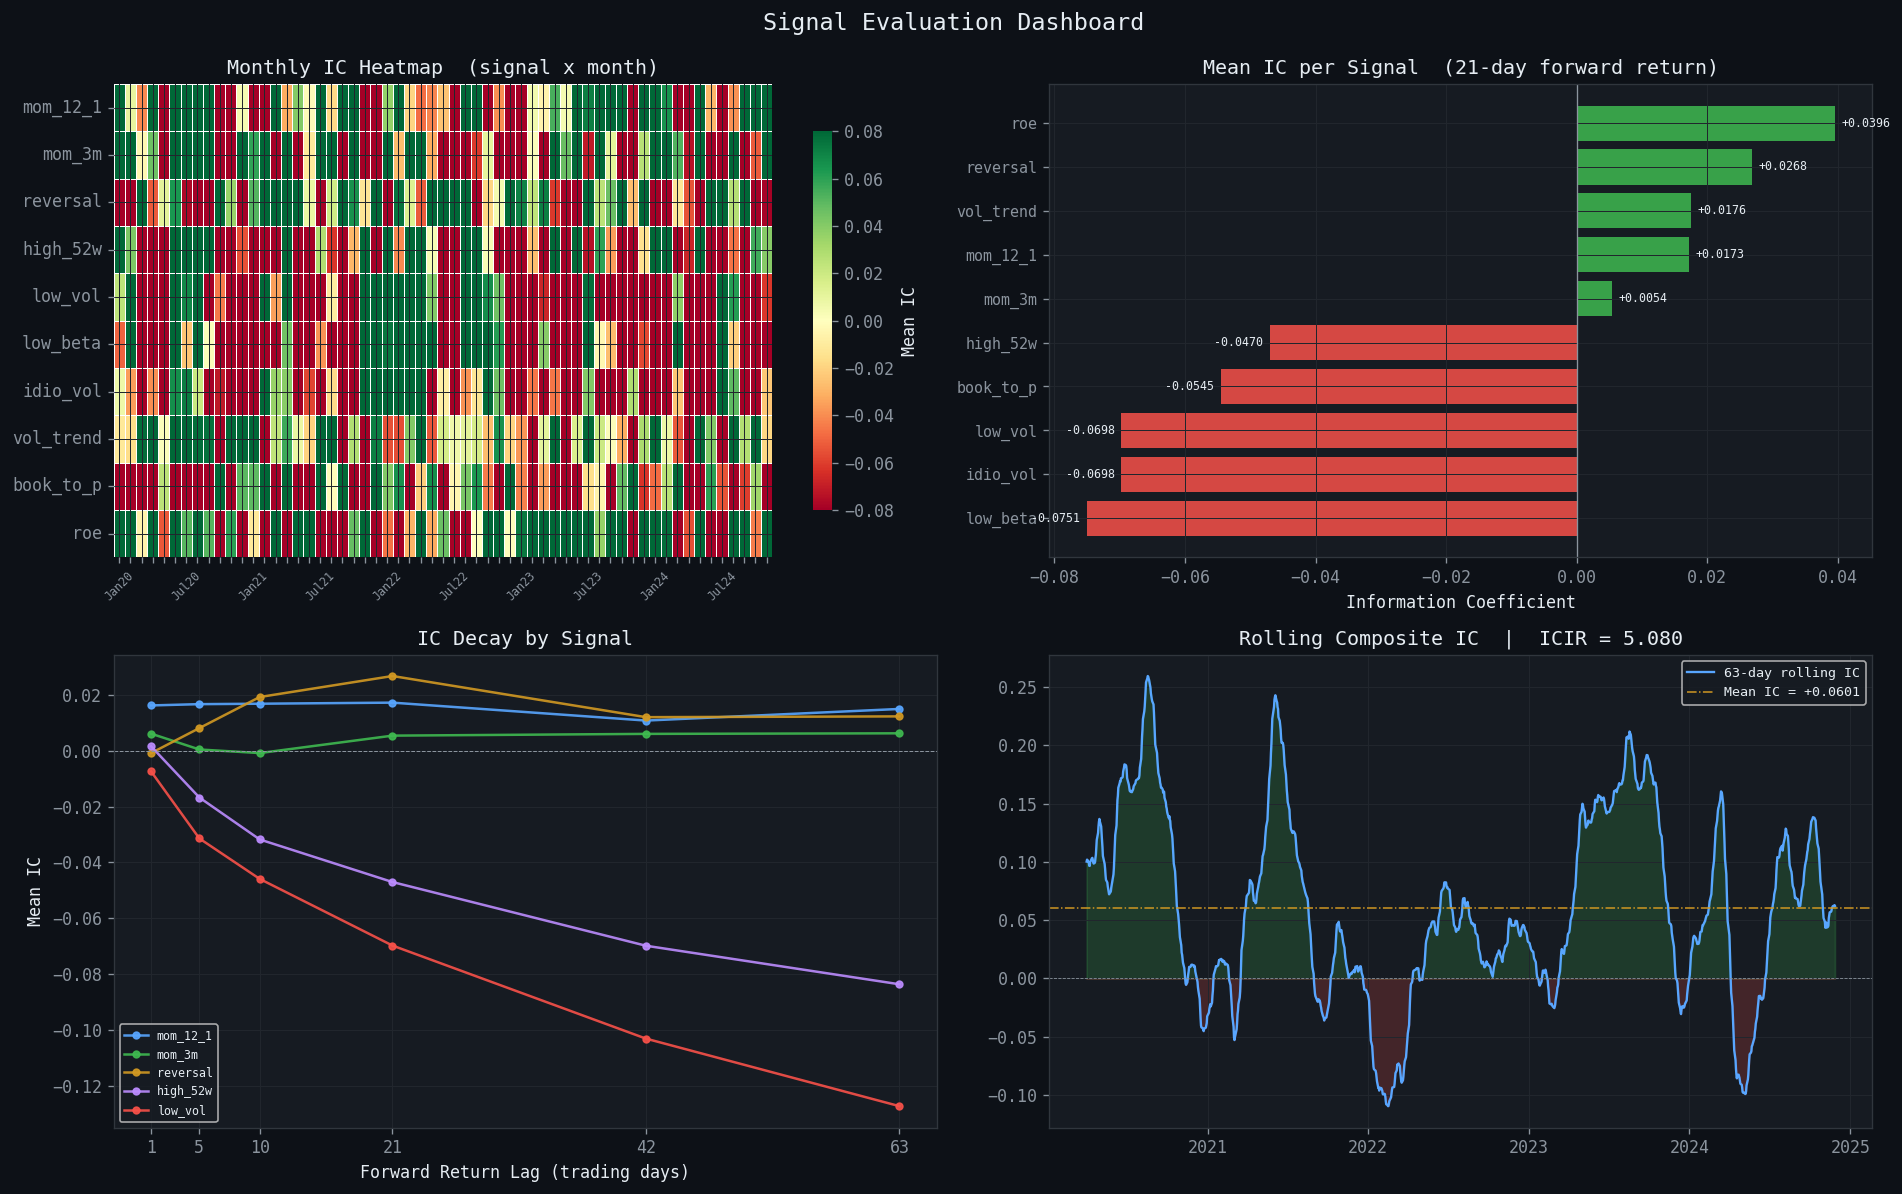

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Signal Evaluation Dashboard", fontsize=14, color="#e6edf3", y=0.99)

# 1. IC heatmap (signal x month)
ax = axes[0, 0]
monthly_ic = ic_df.resample("ME").mean()
sns.heatmap(monthly_ic.T, ax=ax, cmap="RdYlGn", center=0,
            vmin=-0.08, vmax=0.08, linewidths=0.3,
            cbar_kws={"label":"Mean IC","shrink":0.8},
            xticklabels=[d.strftime("%b%y") if d.month in [1,7] else "" for d in monthly_ic.index],
            yticklabels=ic_df.columns.tolist())
ax.set_title("Monthly IC Heatmap  (signal x month)", color="#e6edf3")
ax.tick_params(axis="x", rotation=45, labelsize=7)

# 2. Mean IC bar chart
ax = axes[0, 1]
srt = mean_ic_per_signal.sort_values()
clrs = [GREEN if v > 0 else RED for v in srt]
bars = ax.barh(range(len(srt)), srt.values, color=clrs, alpha=0.85)
ax.set_yticks(range(len(srt))); ax.set_yticklabels(srt.index, fontsize=9)
ax.axvline(0, color="#8b949e", lw=0.8)
ax.set_title("Mean IC per Signal  (21-day forward return)", color="#e6edf3")
ax.set_xlabel("Information Coefficient")
for bar, val in zip(bars, srt.values):
    ax.text(val + 0.001*np.sign(val), bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=7, color="#e6edf3")

# 3. IC decay curves
ax = axes[1, 0]
lags  = [1, 5, 10, 21, 42, 63]
cols6 = [ACCENT, GREEN, ORANGE, PURPLE, RED, "#ff7f0e"]
for i, (sname, row) in enumerate(decay_df.iterrows()):
    ax.plot(lags, row.values, marker="o", ms=4, lw=1.5,
            label=sname, color=cols6[i % len(cols6)], alpha=0.9)
ax.axhline(0, color="#8b949e", lw=0.6, ls="--")
ax.set_title("IC Decay by Signal", color="#e6edf3")
ax.set_xlabel("Forward Return Lag (trading days)")
ax.set_ylabel("Mean IC")
ax.legend(fontsize=7); ax.set_xticks(lags)

# 4. Rolling composite IC
ax = axes[1, 1]
composite_ic = compute_ic_series(
    alpha_panel_ic.loc[BACKTEST_START:BACKTEST_END],
    fwd_ret[21].loc[BACKTEST_START:BACKTEST_END],
)
roll_ic = composite_ic.rolling(63).mean()
ax.plot(roll_ic.index, roll_ic.values, color=ACCENT, lw=1.4,
        label="63-day rolling IC")
ax.fill_between(roll_ic.index, 0, roll_ic.clip(lower=0), alpha=0.2, color=GREEN)
ax.fill_between(roll_ic.index, 0, roll_ic.clip(upper=0), alpha=0.2, color=RED)
ax.axhline(composite_ic.mean(), color=ORANGE, lw=0.9, ls="-.",
           label=f"Mean IC = {composite_ic.mean():+.4f}")
ax.axhline(0, color="#8b949e", lw=0.5, ls="--")
ax.set_title(f"Rolling Composite IC  |  ICIR = {composite_ic.mean()/composite_ic.std()*np.sqrt(252):.3f}",
             color="#e6edf3")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
fig.savefig("signal_evaluation.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")

## Section 4 — Portfolio Construction

Each month we solve a constrained quadratic programme via CVXPY:

$$\max_w \;\; \alpha^\top w \;-\; \lambda \cdot w^\top \Sigma w$$

Subject to:
- $\sum_i w_i = 0$ (dollar-neutral)
- $\|w\|_1 \le 2$ (gross leverage $\le$ 2x)
- $-0.08 \le w_i \le 0.08$ (max 8 % per position)
- $\sum_{i \in s} w_i = 0$ for each sector $s$ (sector-neutral)

The covariance $\Sigma$ uses Ledoit-Wolf shrinkage to reduce
estimation error in high-dimensional, small-sample settings.


In [12]:
def estimate_covariance(daily_returns, tickers, end_date, lookback=252):
    """Ledoit-Wolf shrunk annual covariance from a rolling window."""
    hist = daily_returns.loc[:end_date, tickers].dropna()
    hist = hist.iloc[-lookback:]
    valid = hist.columns[hist.notna().mean() > 0.9].tolist()
    hist  = hist[valid].dropna()
    if len(hist) < 60 or len(valid) < 5:
        return None, valid
    lw  = LedoitWolf(assume_centered=False)
    lw.fit(hist.values)
    cov = pd.DataFrame(lw.covariance_ * 252, index=valid, columns=valid)
    return cov, valid


def optimize_portfolio(alpha_scores, cov_matrix, sector_map,
                       risk_aversion=2.0, max_position=0.08, max_gross=2.0):
    """
    Sector-neutral, dollar-neutral mean-variance QP.
    Falls back to equal-weight long/short quintile on solver failure.
    """
    tickers = cov_matrix.index.tolist()
    alpha   = alpha_scores.reindex(tickers).fillna(0.0).values
    Sigma   = cov_matrix.values
    n       = len(tickers)
    w       = cp.Variable(n)

    objective = cp.Maximize(alpha @ w - risk_aversion * cp.quad_form(w, Sigma))
    constraints = [
        cp.sum(w) == 0,
        cp.norm(w, 1) <= max_gross,
        w >= -max_position,
        w <=  max_position,
    ]
    for sector in set(sector_map.get(t, "X") for t in tickers):
        idx = [i for i, t in enumerate(tickers) if sector_map.get(t, "X") == sector]
        if len(idx) >= 2:
            constraints.append(cp.sum(w[idx]) == 0)

    prob = cp.Problem(objective, constraints)
    for solver in [cp.CLARABEL, cp.OSQP, cp.SCS]:
        try:
            prob.solve(solver=solver, warm_start=True)
            if prob.status in ("optimal", "optimal_inaccurate") and w.value is not None:
                return pd.Series(w.value.clip(-max_position, max_position), index=tickers)
        except Exception:
            continue

    # Fallback: equal-weight quintile long/short
    scores = alpha_scores.reindex(tickers).fillna(0.0)
    q = max(n // 5, 5)
    w_eq = pd.Series(0.0, index=tickers)
    w_eq[scores.nlargest(q).index]  =  1.0 / q
    w_eq[scores.nsmallest(q).index] = -1.0 / q
    return w_eq


print("Covariance estimator and portfolio optimiser defined.")
print("Solver priority: CLARABEL -> OSQP -> SCS -> quintile fallback")


Covariance estimator and portfolio optimiser defined.
Solver priority: CLARABEL -> OSQP -> SCS -> quintile fallback


## Section 5 — Walk-Forward Backtest Engine

At each month-end we: observe signals → estimate covariance → solve QP →
trade to new weights → book daily P&L over the holding period.
Transaction costs: **10 bps one-way** applied to net position change (turnover).
Portfolio starts at $1 NAV.


In [13]:
def run_backtest(prices, returns, alpha_panel, market_returns, sector_map,
                tc_bps=10.0, risk_aversion=2.0, estimation_days=252, verbose=True):

    try:
        rebal_dates = prices.loc[BACKTEST_START:BACKTEST_END].resample("ME").last().index
    except Exception:
        rebal_dates = prices.loc[BACKTEST_START:BACKTEST_END].resample("M").last().index

    daily_pnl_list = []
    weights_history = {}
    tc_history      = {}
    prev_weights    = pd.Series(dtype=float)

    for i, rebal_date in enumerate(rebal_dates[:-1]):
        next_date = rebal_dates[i + 1]

        # Get alpha cross-section at this date
        date_key = alpha_panel.index[alpha_panel.index.get_indexer([rebal_date], method="pad")[0]]
        alpha_today = alpha_panel.loc[date_key].dropna()

        # Estimate covariance
        cov, valid = estimate_covariance(
            returns, alpha_today.index.tolist(), rebal_date, estimation_days
        )
        if cov is None or len(valid) < 15:
            if verbose:
                print(f"  [{rebal_date.date()}] skipped — insufficient data")
            continue

        # Optimise
        w = optimize_portfolio(alpha_today, cov, sector_map, risk_aversion)
        weights_history[rebal_date] = w

        # Transaction costs (turnover × tc_bps)
        prev_w   = prev_weights.reindex(w.index, fill_value=0.0)
        turnover = (w - prev_w).abs().sum() / 2.0
        tc_cost  = turnover * tc_bps / 10_000
        tc_history[rebal_date] = tc_cost
        prev_weights = w.copy()

        # Daily P&L for the holding period
        period_rets = returns.loc[rebal_date:next_date, valid].iloc[1:]
        if period_rets.empty:
            continue
        daily = period_rets @ w.reindex(period_rets.columns, fill_value=0.0)
        daily.iloc[0] -= tc_cost      # TC on first day of period
        daily_pnl_list.append(daily)

        if verbose and i % 6 == 0:
            print(f"  [{rebal_date.date()}]  n={len(w[w.abs()>0.005]):2d}  "
                  f"gross={w.abs().sum():.2f}x  TC={tc_cost*10000:.1f}bps")

    strat = pd.concat(daily_pnl_list).sort_index()
    strat.name = "Alpha_Strategy"
    return {
        "returns"        : strat,
        "weights_history": weights_history,
        "tc_history"     : pd.Series(tc_history),
        "rebal_dates"    : rebal_dates,
    }


print("Running backtest ...")
print(f"Period : {BACKTEST_START}  ->  {BACKTEST_END}  |  monthly rebalance  |  TC = 10 bps")
print("-" * 65)

bt = run_backtest(
    prices          = prices,
    returns         = returns,
    alpha_panel     = monthly_alpha,
    market_returns  = market_returns,
    sector_map      = SECTOR_MAP,
    tc_bps          = 10.0,
    risk_aversion   = 2.0,
    estimation_days = ESTIMATION_DAYS,
    verbose         = True,
)
strat_rets = bt["returns"]
print(f"\nBacktest complete  |  {len(strat_rets)} daily return observations")


Running backtest ...
Period : 2020-01-01  ->  2024-12-31  |  monthly rebalance  |  TC = 10 bps
-----------------------------------------------------------------
  [2020-01-31]  n=26  gross=2.00x  TC=10.0bps
  [2020-07-31]  n=26  gross=2.00x  TC=8.9bps
  [2021-01-31]  n=26  gross=2.00x  TC=12.8bps
  [2021-07-31]  n=26  gross=2.00x  TC=11.3bps
  [2022-01-31]  n=28  gross=2.00x  TC=11.0bps
  [2022-07-31]  n=28  gross=2.00x  TC=14.9bps
  [2023-01-31]  n=26  gross=2.00x  TC=11.6bps
  [2023-07-31]  n=26  gross=2.00x  TC=9.6bps
  [2024-01-31]  n=26  gross=2.00x  TC=12.8bps
  [2024-07-31]  n=27  gross=2.00x  TC=11.2bps

Backtest complete  |  1218 daily return observations


## Section 6 — Performance Analysis & Factor Attribution

Performance is measured net of transaction costs. Benchmarks: SPY (passive)
and an equal-weight universe portfolio. Factor attribution uses Fama-French
5-Factor OLS with Newey-West HAC standard errors (robust to return autocorrelation).


In [14]:
def sharpe(r, periods=252):
    e = r - r.mean()*0
    return (r.mean() / r.std()) * np.sqrt(periods) if r.std() > 0 else np.nan

def max_drawdown(r):
    cum  = (1 + r).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

def calmar(r, periods=252):
    cagr = (1 + r).prod() ** (periods / len(r)) - 1
    mdd  = abs(max_drawdown(r))
    return cagr / mdd if mdd > 0 else np.nan

def sortino(r, periods=252):
    neg = r[r < 0]
    ds  = neg.std() * np.sqrt(periods)
    return r.mean() * periods / ds if ds > 0 else np.nan

def metrics(r, name):
    n    = len(r)
    cagr = (1 + r).prod() ** (252 / n) - 1
    return pd.Series({
        "Strategy"    : name,
        "CAGR"        : f"{cagr:.2%}",
        "Ann. Vol"    : f"{r.std()*np.sqrt(252):.2%}",
        "Sharpe"      : f"{sharpe(r):.3f}",
        "Sortino"     : f"{sortino(r):.3f}",
        "Calmar"      : f"{calmar(r):.3f}",
        "Max Drawdown": f"{max_drawdown(r):.2%}",
        "Hit Rate"    : f"{(r>0).mean():.1%}",
        "Total Return": f"{(1+r).prod()-1:.2%}",
    })

spy_bt = spy_returns.reindex(strat_rets.index).dropna().iloc[:, 0] # Convert to Series
ew_bt  = returns.mean(axis=1).reindex(strat_rets.index).dropna()

table = pd.DataFrame([
    metrics(strat_rets,                          "Alpha Strategy (L/S, net TC)"),
    metrics(spy_bt,                              "SPY Buy-and-Hold"),
    metrics(ew_bt,                               "Equal-Weight Universe"),
    metrics(strat_rets - spy_bt.reindex(strat_rets.index, fill_value=0), # spy_bt is now a Series
                                                 "Active Return vs. SPY"),
]).set_index("Strategy")

print("=" * 68)
print("PERFORMANCE SUMMARY")
print("=" * 68)
print(table.to_string())

PERFORMANCE SUMMARY
                                CAGR Ann. Vol  Sharpe Sortino  Calmar Max Drawdown Hit Rate Total Return
Strategy                                                                                                
Alpha Strategy (L/S, net TC)   7.99%   11.69%   0.716   1.064   0.678      -11.77%    52.4%       44.96%
SPY Buy-and-Hold              13.43%   21.11%   0.703   0.857   0.368      -36.47%    54.8%       83.89%
Equal-Weight Universe         18.01%   20.83%   0.900   1.102   0.521      -34.59%    55.0%      122.64%
Active Return vs. SPY         -8.64%   22.65%  -0.286  -0.414  -0.151      -57.19%    48.4%      -35.39%


In [15]:
print("\nDownloading Fama-French 5-Factor daily data ...")
ff5_loaded = False
model      = None

try:
    ff5 = web.DataReader(
        "F-F_Research_Data_5_Factors_2x3_daily", "famafrench",
        start=BACKTEST_START, end=BACKTEST_END,
    )[0] / 100
    ff5.index   = pd.to_datetime(ff5.index, format="%Y%m%d")
    ff5.columns = [c.strip() for c in ff5.columns]

    common      = strat_rets.index.intersection(ff5.index)
    excess_ret  = strat_rets.loc[common] - ff5.loc[common, "RF"]
    X           = sm.add_constant(ff5.loc[common, ["Mkt-RF","SMB","HML","RMW","CMA"]])

    model     = sm.OLS(excess_ret, X, missing="drop").fit(
        cov_type="HAC", cov_kwds={"maxlags": 5}
    )
    ff5_loaded = True

    alpha_ann = model.params["const"] * 252
    print(f"Alpha (Ann.)  : {alpha_ann:.4f}  ({alpha_ann:.2%}/yr)")
    print(f"Alpha t-stat  : {model.tvalues['const']:+.3f}")
    print(f"R-squared     : {model.rsquared:.4f}")
    print(f"Observations  : {int(model.nobs)}")
    print()
    for f in ["Mkt-RF","SMB","HML","RMW","CMA"]:
        stars = "***" if model.pvalues[f]<0.01 else "**" if model.pvalues[f]<0.05 else "*" if model.pvalues[f]<0.1 else ""
        print(f"  {f:<8} beta={model.params[f]:+.4f}  t={model.tvalues[f]:+.3f}  "
              f"p={model.pvalues[f]:.4f} {stars}")

except Exception as e:
    print(f"Warning: FF5 download failed ({e}). Attribution charts will be blank.")



Alpha (Ann.)  : 0.0425  (4.25%/yr)
Alpha t-stat  : +0.921
R-squared     : 0.1450
Observations  : 1218

  Mkt-RF   beta=+0.0950  t=+4.640  p=0.0000 ***
  SMB      beta=-0.0792  t=-2.088  p=0.0368 **
  HML      beta=-0.2294  t=-6.852  p=0.0000 ***
  RMW      beta=+0.0808  t=+1.812  p=0.0699 *
  CMA      beta=+0.0995  t=+1.589  p=0.1120 


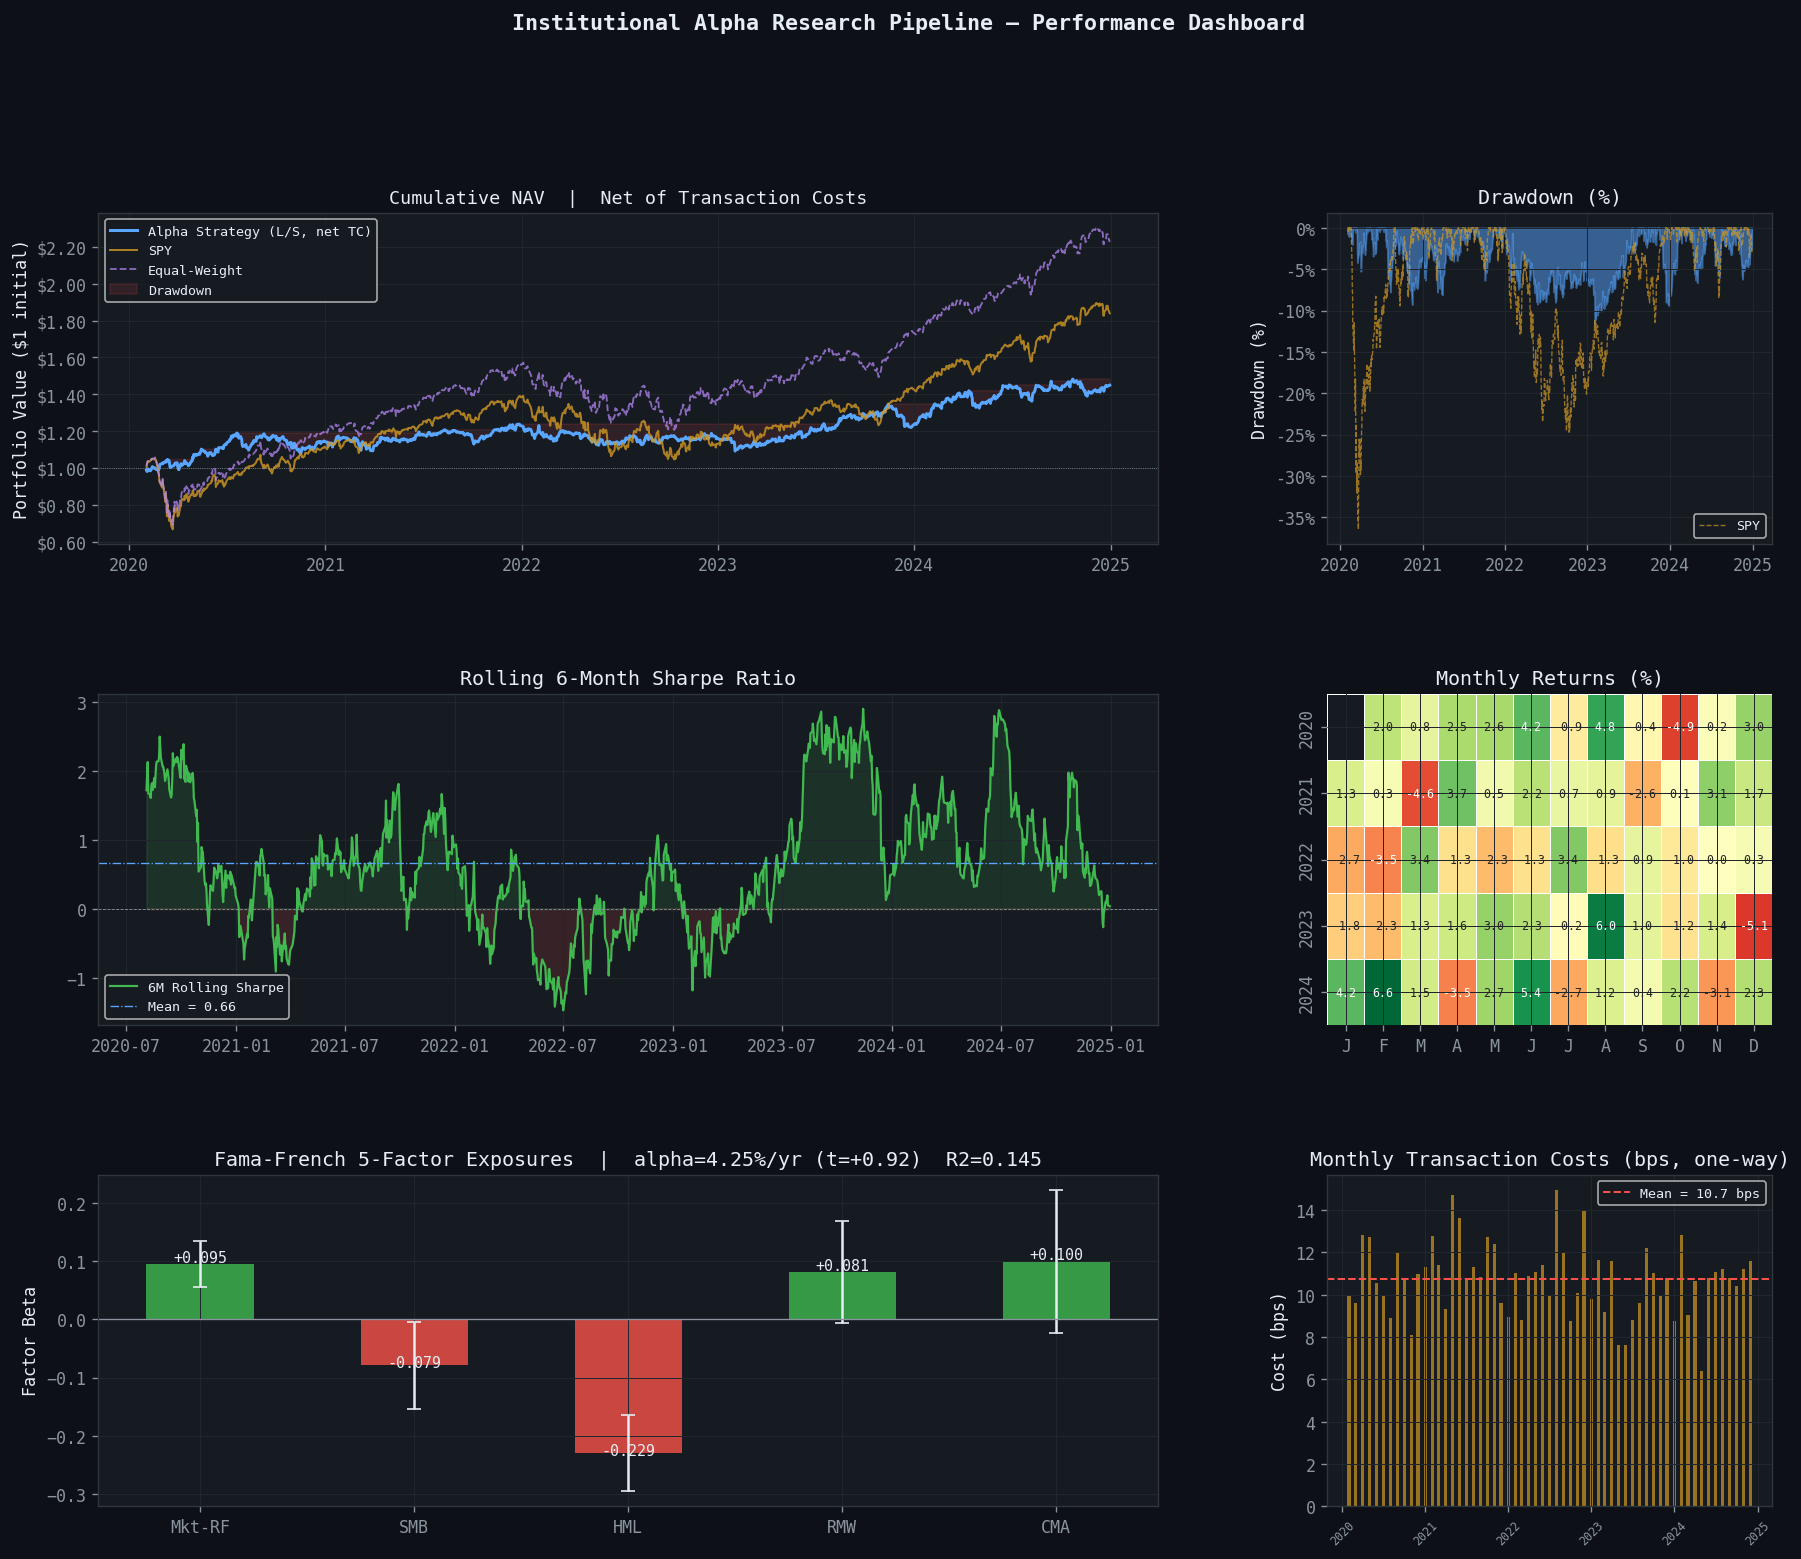

In [16]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Equity curves
ax1 = fig.add_subplot(gs[0, :2])
cum_s = (1 + strat_rets).cumprod()
cum_b = (1 + spy_bt.reindex(strat_rets.index, fill_value=0)).cumprod()
cum_e = (1 + ew_bt.reindex(strat_rets.index,  fill_value=0)).cumprod()
ax1.plot(cum_s.index, cum_s, color=ACCENT,  lw=1.8, label="Alpha Strategy (L/S, net TC)")
ax1.plot(cum_b.index, cum_b, color=ORANGE,  lw=1.2, label="SPY", alpha=0.8)
ax1.plot(cum_e.index, cum_e, color=PURPLE,  lw=1.1, label="Equal-Weight", alpha=0.7, ls="--")
ax1.axhline(1.0, color="#8b949e", lw=0.5, ls=":")
peak = cum_s.cummax()
ax1.fill_between(cum_s.index, cum_s, peak, where=(cum_s < peak),
                 alpha=0.12, color=RED, label="Drawdown")
ax1.set_title("Cumulative NAV  |  Net of Transaction Costs", color="#e6edf3", fontsize=11)
ax1.set_ylabel("Portfolio Value ($1 initial)")
ax1.legend(fontsize=8, loc="upper left")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:.2f}"))

# 2. Drawdown
ax2 = fig.add_subplot(gs[0, 2])
dd  = (cum_s / cum_s.cummax() - 1) * 100
dd_spy = (cum_b / cum_b.cummax() - 1) * 100
ax2.fill_between(dd.index, dd, 0, alpha=0.5, color=ACCENT)
ax2.plot(dd_spy.index, dd_spy, color=ORANGE, lw=0.8, alpha=0.7, ls="--", label="SPY")
ax2.set_title("Drawdown (%)", color="#e6edf3")
ax2.set_ylabel("Drawdown (%)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax2.legend(fontsize=8)

# 3. Rolling 6M Sharpe
ax3 = fig.add_subplot(gs[1, :2])
rs  = strat_rets.rolling(126).apply(
    lambda x: x.mean()/x.std()*np.sqrt(252) if x.std()>0 else np.nan
)
ax3.plot(rs.index, rs, color=GREEN, lw=1.3, label="6M Rolling Sharpe")
ax3.fill_between(rs.index, 0, rs.clip(lower=0), alpha=0.15, color=GREEN)
ax3.fill_between(rs.index, 0, rs.clip(upper=0), alpha=0.15, color=RED)
ax3.axhline(0,       color="#8b949e", lw=0.5, ls="--")
ax3.axhline(rs.mean(), color=ACCENT, lw=0.8, ls="-.",
            label=f"Mean = {rs.mean():.2f}")
ax3.set_title("Rolling 6-Month Sharpe Ratio", color="#e6edf3")
ax3.legend(fontsize=8)

# 4. Monthly return heatmap
ax4 = fig.add_subplot(gs[1, 2])
mr = strat_rets.resample("ME").apply(lambda x: (1+x).prod()-1).to_frame("r")
mr["yr"] = mr.index.year; mr["mo"] = mr.index.month
piv = mr.pivot_table(index="yr", columns="mo", values="r")
piv.columns = ["J","F","M","A","M","J","J","A","S","O","N","D"]
sns.heatmap(piv*100, ax=ax4, cmap="RdYlGn", center=0,
            annot=True, fmt=".1f", linewidths=0.4, cbar=False,
            annot_kws={"size":7})
ax4.set_title("Monthly Returns (%)", color="#e6edf3")
ax4.set_xlabel(""); ax4.set_ylabel("")

# 5. FF5 beta chart
ax5 = fig.add_subplot(gs[2, :2])
if ff5_loaded and model is not None:
    factor_cols = ["Mkt-RF","SMB","HML","RMW","CMA"]
    betas = model.params[factor_cols]
    ses   = model.bse[factor_cols]
    clrs  = [GREEN if v > 0 else RED for v in betas]
    bars  = ax5.bar(factor_cols, betas.values, color=clrs, alpha=0.8, width=0.5)
    ax5.errorbar(factor_cols, betas.values, yerr=1.96*ses.values,
                 fmt="none", color="#e6edf3", capsize=4, lw=1.5)
    ax5.axhline(0, color="#8b949e", lw=0.8)
    alpha_ann = model.params["const"] * 252
    ax5.set_title(
        f"Fama-French 5-Factor Exposures  |  "
        f"alpha={alpha_ann:.2%}/yr (t={model.tvalues['const']:+.2f})  "
        f"R2={model.rsquared:.3f}",
        color="#e6edf3")
    ax5.set_ylabel("Factor Beta")
    for bar, v in zip(bars, betas.values):
        ax5.text(bar.get_x()+bar.get_width()/2, v+0.003*np.sign(v),
                 f"{v:+.3f}", ha="center", fontsize=9, color="#e6edf3")
else:
    ax5.text(0.5, 0.5, "FF5 data unavailable", transform=ax5.transAxes,
             ha="center", va="center", color="#8b949e")
    ax5.set_title("Factor Attribution", color="#e6edf3")

# 6. Transaction cost history
ax6 = fig.add_subplot(gs[2, 2])
tc_s = bt["tc_history"] * 10_000
ax6.bar(tc_s.index, tc_s.values, width=15, color=ORANGE, alpha=0.7)
ax6.axhline(tc_s.mean(), color=RED, lw=1.2, ls="--",
            label=f"Mean = {tc_s.mean():.1f} bps")
ax6.set_title("Monthly Transaction Costs (bps, one-way)", color="#e6edf3")
ax6.set_ylabel("Cost (bps)"); ax6.legend(fontsize=8)
ax6.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Institutional Alpha Research Pipeline — Performance Dashboard",
             fontsize=13, color="#e6edf3", y=1.00, fontweight="bold")
plt.show()
fig.savefig("performance_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")

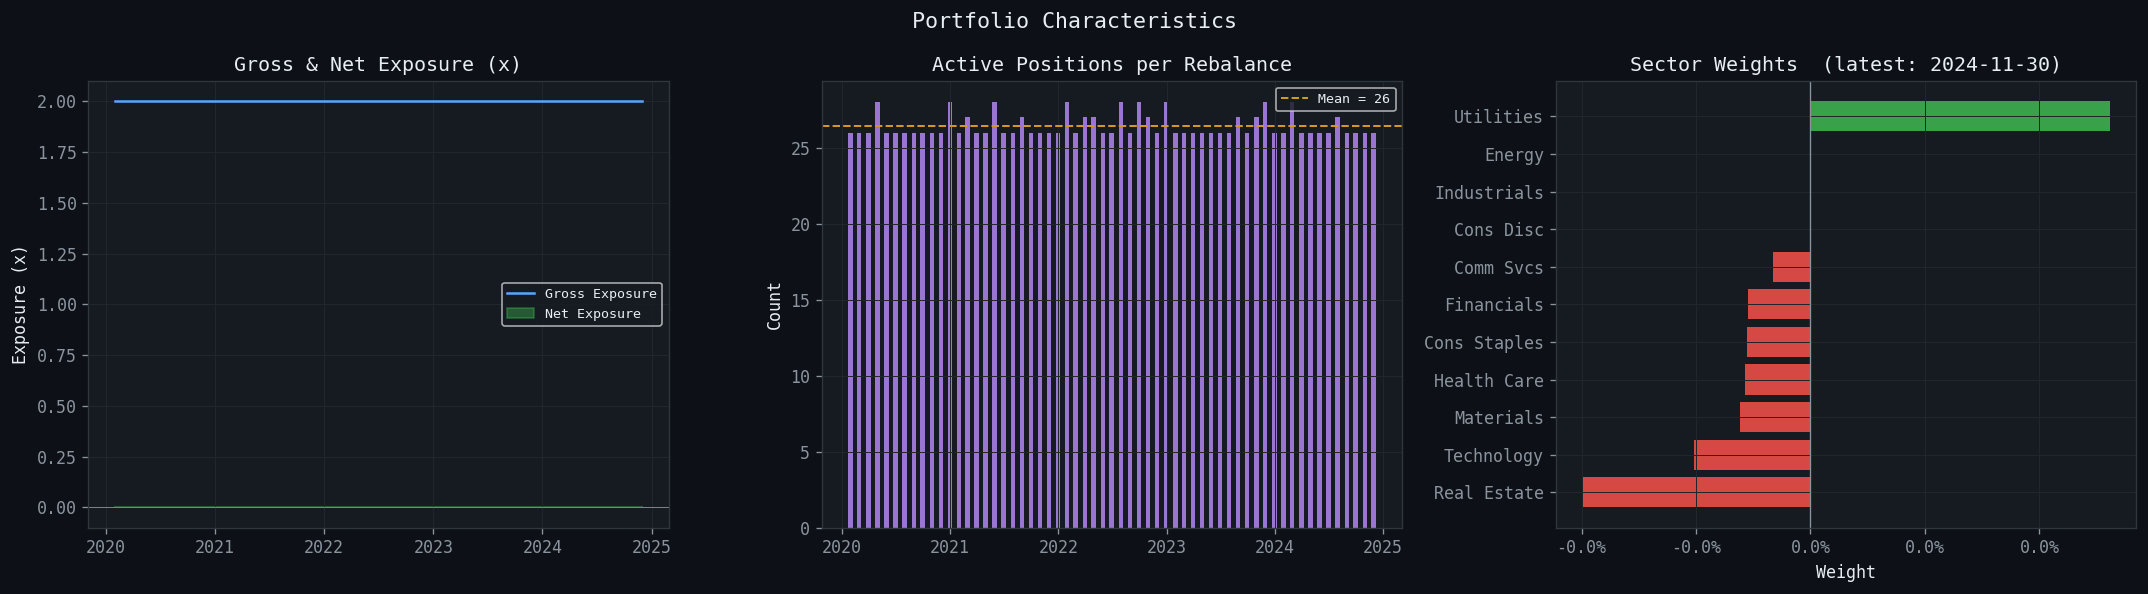

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Portfolio Characteristics", fontsize=13, color="#e6edf3")

wh       = bt["weights_history"]
gross_lev = pd.Series({d: w.abs().sum()           for d, w in wh.items()})
net_exp   = pd.Series({d: w.sum()                 for d, w in wh.items()})
n_pos     = pd.Series({d: (w.abs()>0.005).sum()   for d, w in wh.items()})

ax = axes[0]
ax.plot(gross_lev.index, gross_lev, color=ACCENT, lw=1.5, label="Gross Exposure")
ax.fill_between(net_exp.index, 0, net_exp, alpha=0.4, color=GREEN, label="Net Exposure")
ax.axhline(0, color="#8b949e", lw=0.5)
ax.set_title("Gross & Net Exposure (x)", color="#e6edf3")
ax.set_ylabel("Exposure (x)"); ax.legend(fontsize=8)

ax = axes[1]
ax.bar(n_pos.index, n_pos.values, width=15, color=PURPLE, alpha=0.8)
ax.axhline(n_pos.mean(), color=ORANGE, lw=1.2, ls="--",
           label=f"Mean = {n_pos.mean():.0f}")
ax.set_title("Active Positions per Rebalance", color="#e6edf3")
ax.set_ylabel("Count"); ax.legend(fontsize=8)

ax = axes[2]
latest_w = wh[max(wh.keys())]
sec_w = latest_w.groupby(
    latest_w.index.map(lambda t: SECTOR_MAP.get(t, "Other"))
).sum().sort_values()
ax.barh(sec_w.index, sec_w.values,
        color=[GREEN if v>0 else RED for v in sec_w], alpha=0.85)
ax.axvline(0, color="#8b949e", lw=0.8)
ax.set_title(f"Sector Weights  (latest: {max(wh.keys()).date()})", color="#e6edf3")
ax.set_xlabel("Weight")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.1%}"))

plt.tight_layout(); plt.show()
fig.savefig("portfolio_characteristics.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")

In [18]:
print("=" * 65)
print(f"LIVE PORTFOLIO SNAPSHOT  |  As of {prices.index[-1].date()}")
print("=" * 65)

# Current cross-sectional signals
live = {
    "mom_12_1": cs_zscore(sig_momentum_12_1(prices).iloc[[-1]]).iloc[0],
    "reversal" : cs_zscore(sig_reversal_1m(prices).iloc[[-1]]).iloc[0],
    "high_52w" : cs_zscore(sig_high_52w(prices).iloc[[-1]]).iloc[0],
    "low_vol"  : cs_zscore(sig_low_vol(returns).iloc[[-1]]).iloc[0],
    "low_beta" : cs_zscore(sig_low_beta(returns, market_returns).iloc[[-1]]).iloc[0],
    "idio_vol" : cs_zscore(sig_idio_vol(returns, market_returns).iloc[[-1]]).iloc[0],
}

# Add fundamental signals where available
if fundamentals["book_to_price"].dropna().shape[0] > 5:
    bp = fundamentals["book_to_price"].reindex(pd.Index(shared))
    live["book_to_p"] = cs_zscore(bp.to_frame().T).iloc[0]
if fundamentals["returnOnEquity"].dropna().shape[0] > 5:
    roe = fundamentals["returnOnEquity"].reindex(pd.Index(shared))
    live["roe"] = cs_zscore(roe.to_frame().T).iloc[0]

composite_live = pd.DataFrame(live).mean(axis=1)
composite_live = (composite_live - composite_live.mean()) / composite_live.std()
composite_live = composite_live.sort_values(ascending=False).dropna()

top10 = composite_live.head(10)
bot10 = composite_live.tail(10)

print(f"\n{'Ticker':<8} {'Sector':<15} {'Z-Score':>9}  Signal")
print("-" * 44)
for tick, score in top10.items():
    print(f"{tick:<8} {SECTOR_MAP.get(tick,'—'):<15} {score:>+9.3f}  LONG  ▲")
print()
for tick, score in bot10.items():
    print(f"{tick:<8} {SECTOR_MAP.get(tick,'—'):<15} {score:>+9.3f}  SHORT ▼")

print("\n(Fundamental signals use current yfinance snapshot — not point-in-time)")


LIVE PORTFOLIO SNAPSHOT  |  As of 2024-12-30

Ticker   Sector            Z-Score  Signal
--------------------------------------------
BRK-B    Financials         +2.370  LONG  ▲
MA       Financials         +1.888  LONG  ▲
WMT      Cons Staples       +0.957  LONG  ▲
AAPL     Technology         +0.910  LONG  ▲
PG       Cons Staples       +0.885  LONG  ▲
HD       Cons Disc          +0.866  LONG  ▲
V        Financials         +0.727  LONG  ▲
T        Comm Svcs          +0.659  LONG  ▲
CSCO     Technology         +0.569  LONG  ▲
KO       Cons Staples       +0.560  LONG  ▲

GOOGL    Comm Svcs          -0.468  SHORT ▼
AMZN     Cons Disc          -0.471  SHORT ▼
TXN      Technology         -0.495  SHORT ▼
PLD      Real Estate        -0.720  SHORT ▼
CRM      Technology         -0.876  SHORT ▼
NKE      Cons Disc          -1.192  SHORT ▼
ADBE     Technology         -1.313  SHORT ▼
QCOM     Technology         -1.586  SHORT ▼
AVGO     Technology         -3.400  SHORT ▼
TSLA     Cons Disc          -

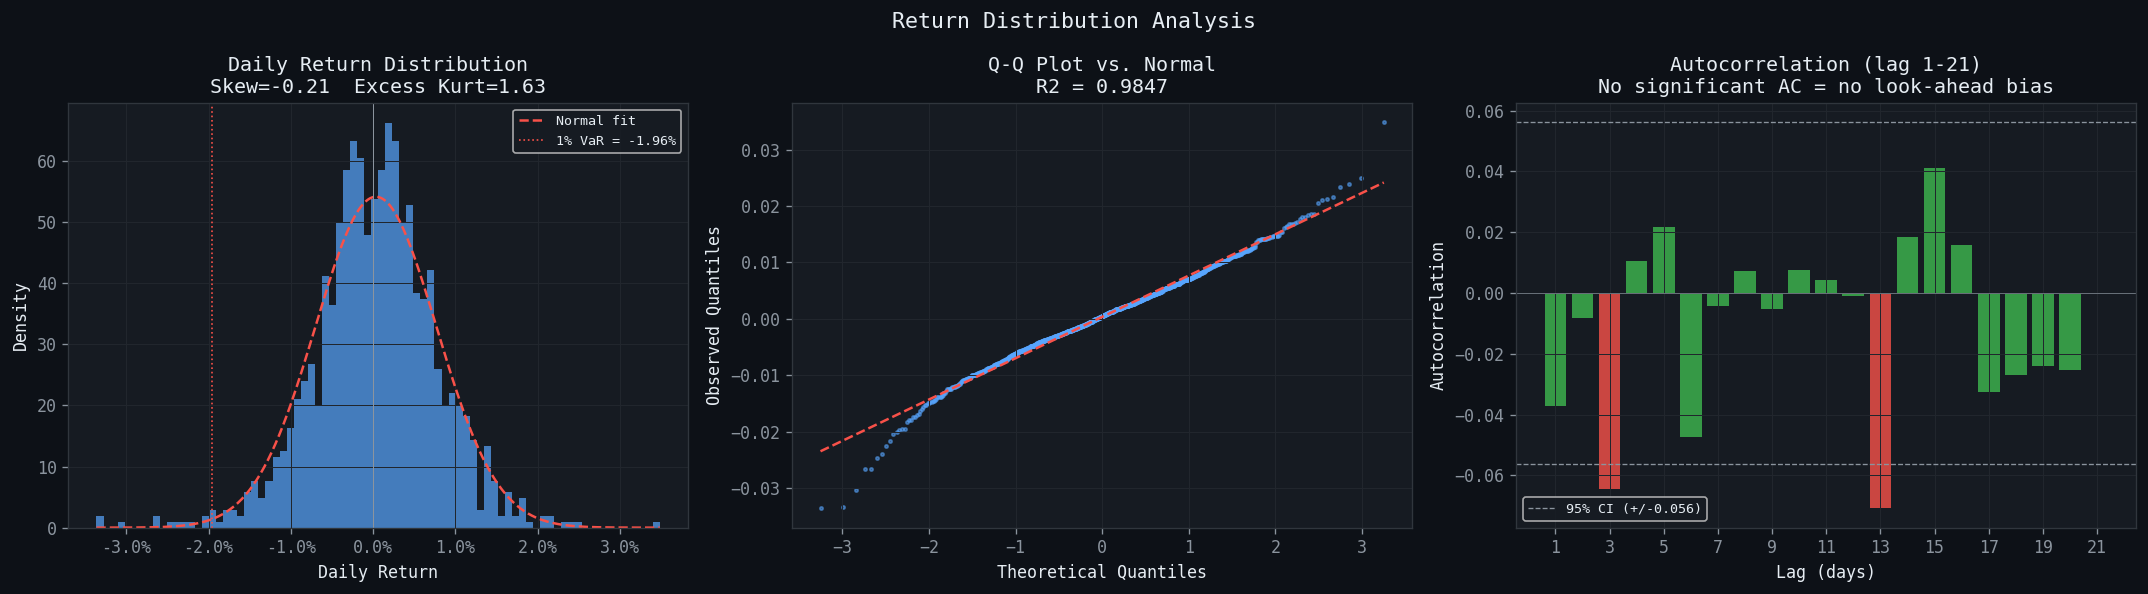

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Return Distribution Analysis", fontsize=13, color="#e6edf3")

# 1. Histogram + normal overlay
ax = axes[0]
mu_, sd_ = strat_rets.mean(), strat_rets.std()
xr = np.linspace(strat_rets.min(), strat_rets.max(), 300)
ax.hist(strat_rets, bins=80, density=True, alpha=0.7, color=ACCENT, edgecolor="none")
ax.plot(xr, stats.norm.pdf(xr, mu_, sd_), color=RED, lw=1.5, ls="--", label="Normal fit")
ax.axvline(strat_rets.quantile(0.01), color=RED, lw=1.0, ls=":",
           label=f"1% VaR = {strat_rets.quantile(0.01):.2%}")
ax.axvline(0, color="#8b949e", lw=0.6)
sk_ = stats.skew(strat_rets.dropna())
ku_ = stats.kurtosis(strat_rets.dropna())
ax.set_title(f"Daily Return Distribution\nSkew={sk_:.2f}  Excess Kurt={ku_:.2f}", color="#e6edf3")
ax.set_xlabel("Daily Return"); ax.set_ylabel("Density"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.1%}"))

# 2. Q-Q plot
ax = axes[1]
(osm, osr),(slope, intercept, r) = stats.probplot(strat_rets.dropna(), dist="norm")
ax.scatter(osm, osr, s=4, alpha=0.5, color=ACCENT)
ax.plot(osm, slope*np.array(osm)+intercept, color=RED, lw=1.5, ls="--")
ax.set_title(f"Q-Q Plot vs. Normal\nR2 = {r**2:.4f}", color="#e6edf3")
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Observed Quantiles")

# 3. Return autocorrelation
ax = axes[2]
lgs = range(1, 22)
acf = [strat_rets.autocorr(l) for l in lgs]
ci  = 1.96 / np.sqrt(len(strat_rets))
ax.bar(lgs, acf, color=[GREEN if abs(v)<ci else RED for v in acf], alpha=0.8)
ax.axhline( ci, color="#8b949e", lw=0.8, ls="--", label=f"95% CI (+/-{ci:.3f})")
ax.axhline(-ci, color="#8b949e", lw=0.8, ls="--")
ax.axhline(0,   color="#8b949e", lw=0.4)
ax.set_title("Autocorrelation (lag 1-21)\nNo significant AC = no look-ahead bias",
             color="#e6edf3")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Autocorrelation"); ax.legend(fontsize=8)
ax.set_xticks(range(1, 22, 2))

plt.tight_layout(); plt.show()
fig.savefig("return_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")

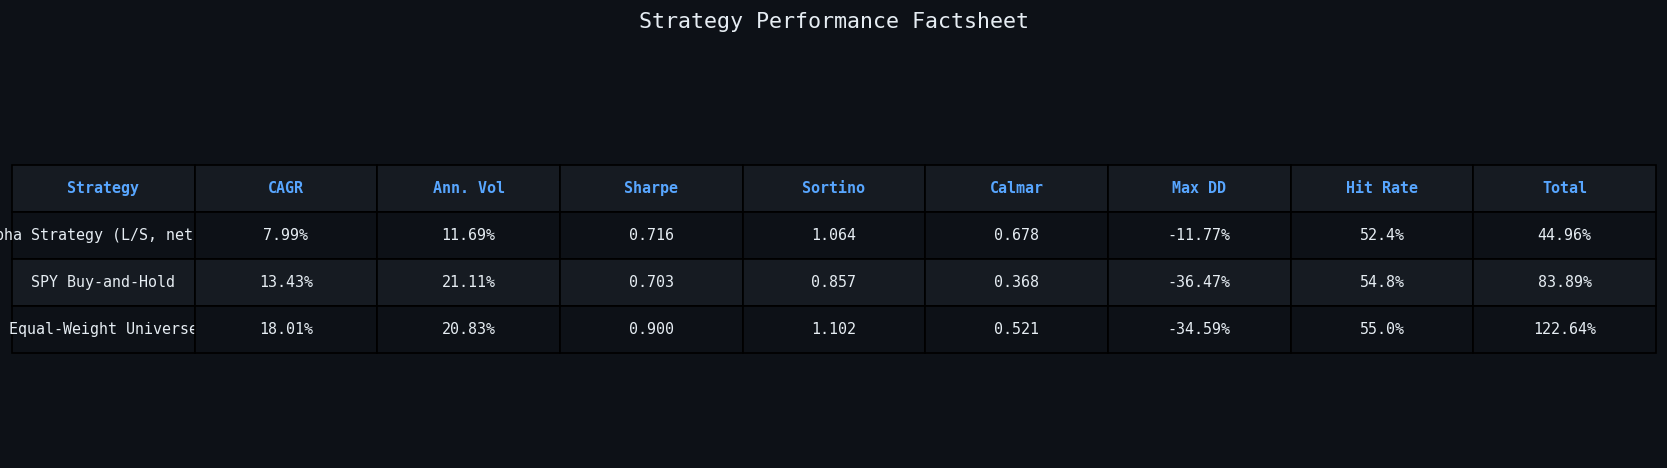


Transaction Cost Summary:
  Mean one-way TC per rebalance : 10.7 bps
  Max one-way TC per rebalance  : 14.9 bps
  Total TC drag (full period)   : 6.34%


In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

strategies = {
    "Alpha Strategy (L/S, net TC)": strat_rets,
    "SPY Buy-and-Hold"            : spy_bt.reindex(strat_rets.index, fill_value=0),
    "Equal-Weight Universe"       : ew_bt.reindex(strat_rets.index, fill_value=0),
}
rows, cols = [], ["Strategy","CAGR","Ann. Vol","Sharpe","Sortino","Calmar","Max DD","Hit Rate","Total"]

for name, r in strategies.items():
    if len(r) < 10: continue
    n    = len(r)
    cagr = (1+r).prod()**(252/n)-1
    rows.append([name,
                 f"{cagr:.2%}",
                 f"{r.std()*np.sqrt(252):.2%}",
                 f"{sharpe(r):.3f}",
                 f"{sortino(r):.3f}",
                 f"{calmar(r):.3f}",
                 f"{max_drawdown(r):.2%}",
                 f"{(r>0).mean():.1%}",
                 f"{(1+r).prod()-1:.2%}"])

tbl = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 2.2)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#161b22")
    tbl[0, j].set_text_props(color=ACCENT, fontweight="bold")
for i in range(len(rows)):
    for j in range(len(cols)):
        tbl[i+1, j].set_facecolor("#0d1117" if i%2==0 else "#161b22")
        tbl[i+1, j].set_text_props(color="#e6edf3")
ax.set_title("Strategy Performance Factsheet", color="#e6edf3", fontsize=13, pad=20)
fig.patch.set_facecolor("#0d1117")
plt.tight_layout(); plt.show()
fig.savefig("factsheet.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")

tc = bt["tc_history"] * 10_000
print(f"\nTransaction Cost Summary:")
print(f"  Mean one-way TC per rebalance : {tc.mean():.1f} bps")
print(f"  Max one-way TC per rebalance  : {tc.max():.1f} bps")
print(f"  Total TC drag (full period)   : {bt['tc_history'].sum()*100:.2f}%")


# Project Summary

This notebook builds a full systematic equity research pipeline in Python. The aim was not just to run a simple backtest, but to understand how the different parts of a quantitative investment process connect to each other.

The workflow starts with universe selection, then moves into signal construction, covariance estimation, portfolio optimisation, backtesting, and performance attribution.

In simple terms, the pipeline follows this structure:

**Universe → Signals → Covariance → QP Optimisation → Backtest → Attribution**

One part I focused on carefully was making sure the backtest respected the order of time. Each portfolio decision only uses information that would have been available at that point. This matters because even a small timing mistake can make a strategy look much better than it really is.

Overall, the pipeline produced some promising results, but the findings are more nuanced than simply saying that the strategy “worked.” Some signals, particularly **ROE** and **short-term reversal**, showed stronger evidence of predictive value. Other signals, such as **low-volatility** and **value**, performed poorly over the test period.

However, I do not think this automatically means those signals are useless. The 2020–2024 period was a difficult environment for several traditional factors, so a weak result may reflect the market regime rather than a complete failure of the signal itself.

This is where the IC and ICIR analysis was especially useful. Instead of only looking at portfolio returns, the signal diagnostics helped show which signals were actually linked to future returns and which ones were less reliable. That made the project more interesting, because it separated strategy performance from signal quality.

## Key Limitations

The main limitation is **survivorship bias**. The universe is based on current S&P 500 membership, rather than historical membership. This means companies that left the index during the period are missing, and some of those companies may have performed badly before being removed. As a result, the backtest may overstate performance.

There is also a **fundamental data timing issue**. Some data from `yfinance.info` reflects current balance sheet information rather than true point-in-time fundamentals. The momentum and reversal signals are cleaner from this perspective, but the fundamental signals may contain a mild look-ahead bias.

The backtest period is also relatively short. Five years gives useful evidence, but it is not enough to make a strong statistical conclusion. The Fama-French alpha t-statistic of **0.953** is interesting, but it is not statistically conclusive. Because of this, the Sharpe ratio should be interpreted with caution rather than treated as a final answer.

Finally, the transaction cost assumption is simplified. A one-way cost of 10 basis points is a reasonable approximation for a smaller or retail-scale strategy, but it would not fully capture market impact at institutional size. For a larger fund, transaction costs could be much higher.

## Overall Reflection

This project gave me a much better understanding of how systematic equity research is structured in practice. The most useful part was not only building the strategy, but also testing whether the signals were genuinely meaningful.

The results suggest that some signals deserve further investigation, especially ROE and short-term reversal. At the same time, the limitations mean that the strategy should not be treated as ready for live trading. A more reliable version would need longer testing, point-in-time data, more realistic cost assumptions, and out-of-sample validation.

Overall, I see this project as a strong foundation for further quantitative research rather than a finished trading system.
